In [ ]:
# Import dependencies

import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import math

In [58]:
# Generating the data
# We will generate this many sample data points
SAMPLES = 1000
# Setting a "seed" value, so we get te same random numbers each time we run
# notebook. Any number can be used here
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Generate a uniformly distributed set of random numbers in the range from 
# 0 to 2n, which covers a complete sienwave oscillation.
x_value = np.random.uniform(low=0, high=2*math.pi, size=SAMPLES)

#Shuffle the values to guarantee they are not in order
np.random.shuffle(x_value)

# Calculate the corresponding sine wave
y_value = np.sin(x_value)

# Add a small random number to each y value 
y_values = y_value + 0.17 * np.random.randn(*y_value.shape)





In [59]:
# 60 % of our data will will be used for the training, 20% will be for testing
# the remaining 20% will be validation.
# Calculating the indeces of each section

Train_split = int(0.6 * SAMPLES)
Test_split = int(0.2 * SAMPLES + Train_split)

# Use np.split to chop our data into three parts.
# The second argument to np.split is an array of indices where the data will be 
# split. We provide two indices, so that data will be divided into three chunks

x_train, x_val, x_test = np.split(x_value, [Train_split, Test_split])
y_train, y_val, y_test = np.split(y_values, [Train_split, Test_split])

# Double checking that our splits add up correctly
assert(x_train.size + x_val.size + x_test.size) == SAMPLES

In [63]:
# Using keras to create a simple model architecture 
from tensorflow.keras import layers
model_1 = tf.keras.Sequential()

# First layer takes a scalar input and feeds it through 16 "neurons". The 
# neurons decide whether to activate based on "relu" activation function
model_1.add(layers.Dense(16, activation='relu', input_shape=(1,)))

# Final layer is a single neuron
model_1.add(layers.Dense(1))

# Compiling the model using a standard optimizer and loss function for linear regresssion
model_1.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# print model summary
model_1.summary()

c:\Users\tajbi\anaconda3\envs\tinyml\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Training the first model
history_1 = model_1.fit(x_train, y_train, epochs=1000, batch_size=16,
                        validation_data=(x_val, y_val))

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1470 - mae: 0.9097 - val_loss: 0.7507 - val_mae: 0.7797
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5699 - mae: 0.6689 - val_loss: 0.5303 - val_mae: 0.6351
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4592 - mae: 0.5858 - val_loss: 0.4716 - val_mae: 0.5893
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4171 - mae: 0.5556 - val_loss: 0.4325 - val_mae: 0.5613
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3832 - mae: 0.5327 - val_loss: 0.3970 - val_mae: 0.5346
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3523 - mae: 0.5106 - val_loss: 0.3647 - val_mae: 0.5096
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3245 - mae: 0.4900 - val_loss: 0.3356 - val_mae: 0.4873
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2997 - mae: 0.4714 - val_loss: 0.3099 - val_mae: 0.4678
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [ ]:

pred_1 = model_1.predict(x_train)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


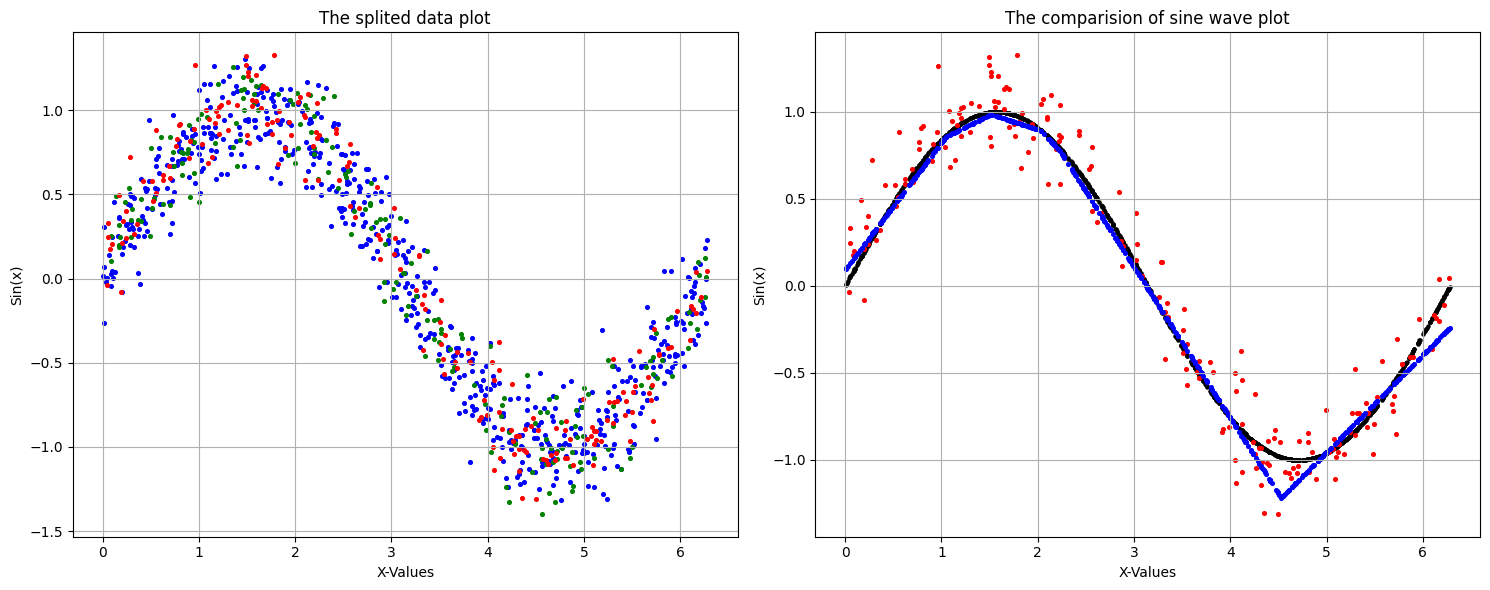

In [72]:
# Plot the data
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(x_train, y_train, s=7, color="blue")
axes[0].scatter(x_val, y_val, s=7, color="green")
axes[0].scatter(x_test, y_test, s=7, color="red")
axes[0].grid(True)
axes[0].set_title("The splited data plot")
axes[0].set_xlabel("X-Values")
axes[0].set_ylabel("Sin(x)")

axes[1].scatter(x_value, y_value,s=5, color='black')
axes[1].scatter(x_test, y_test, s=7, color="red")
axes[1].scatter(x_train, pred_1, s=7, color="blue")
axes[1].grid(True)
axes[1].set_title("The comparision of sine wave plot")
axes[1].set_xlabel("X-Values")
axes[1].set_ylabel("Sin(x)")

plt.tight_layout()
plt.show()